In [ ]:
import pandas as pd #data wrangling/cleaning
import seaborn as sns # scientific ploting/modeling
import matplotlib.pyplot as plt # plot = ggplot2

from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.graphics.factorplots import interaction_plot
import matplotlib.pyplot as plt


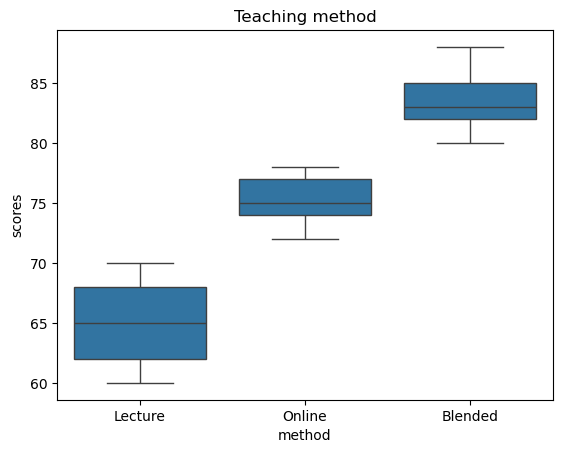

             df  sum_sq     mean_sq         F    PR(>F)
C(method)   2.0   867.6  433.800000  40.66875  0.000005
Residual   12.0   128.0   10.666667       NaN       NaN


In [9]:
# **1 Teaching Methods (Education)

method = ["Lecture"]*5 + ["Online"]*5 + ["Blended"]*5
scores = [60,65,70,62,68,72,75,78,74,77,80,82,85,83,88]
#df=data.frame(method,scores)
df1=pd.DataFrame({"method": method, "scores":scores})
#boxplot(scores~method, data=df)
sns.boxplot(x="method", y = "scores", data =df1)
plt.title("Teaching method")
plt.show()

#model=lm(scores~method , data = df)
model = ols ('scores~C(method)',data=df1) .fit()
print(anova_lm(model))

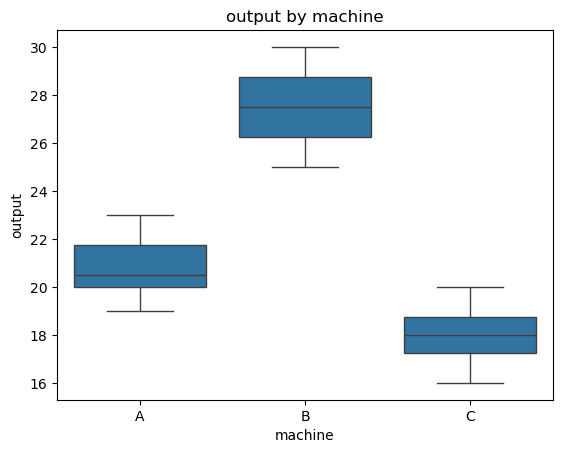

              df      sum_sq     mean_sq          F        PR(>F)
C(machine)   2.0  285.444444  142.722222  55.847826  1.121945e-07
Residual    15.0   38.333333    2.555556        NaN           NaN


In [3]:
## 2 Machine Types (Manufacturing)
machine = ["A"]*6 + ["B"]*6 +["C"]*6
output = [20,22,19,23,21,20, 25,27,26,28,29,30, 18,17,19,16,20,18]

df= pd.DataFrame({"machine": machine, "output":output})

sns.boxplot(x= "machine", y = "output", data = df)
plt.title("output by machine")
plt.show()
model = ols ('output~ C(machine)', data=df).fit()
print(anova_lm(model))


  Campaign  sales
0   Social    200
1   Social    210
2   Social    190
3   Social    205
4   Social    198


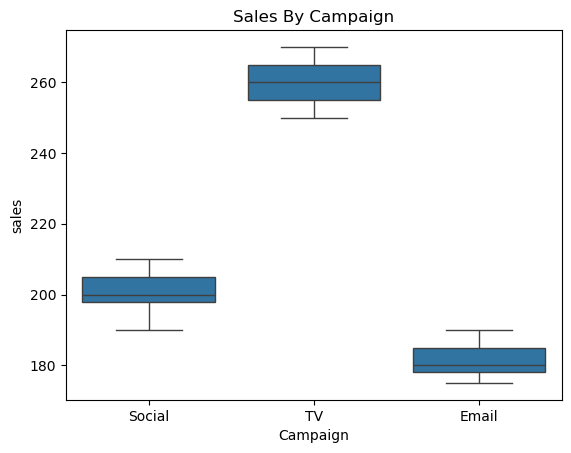

In [ ]:
## 3 Marketing Campaigns
Campaign = ["Social"]*5 + ["TV"]*5 + ["Email"]*5
sales = [200,210,190,205,198, 250,260,255,270,265, 180,175,190,185,178]

df3=pd.DataFrame({"Campaign": Campaign, "sales":sales})
print(df1.head())
sns.boxplot(x="Campaign",y = "sales", data=df3)
plt.title("Sales By Campaign")
plt.show()


                   df        sum_sq       mean_sq             F    PR(>F)
C(drug)           2.0  1.200000e+01  6.000000e+00  6.000000e+00  0.015625
C(dose)           1.0  4.050000e+01  4.050000e+01  4.050000e+01  0.000036
C(drug):C(dose)   2.0  2.963159e-29  1.481579e-29  1.481579e-29  1.000000
Residual         12.0  1.200000e+01  1.000000e+00           NaN       NaN


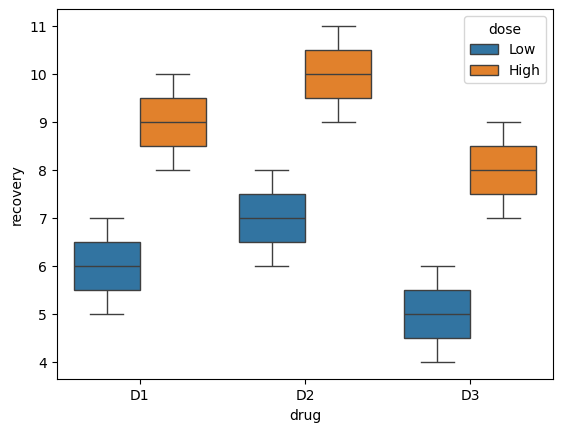

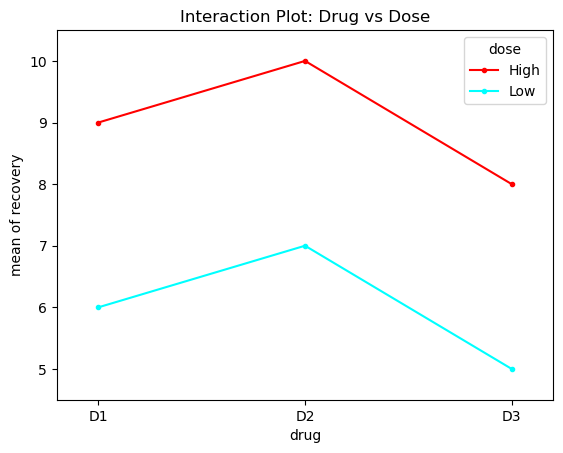

In [ ]:
# 4. Drug Dosage
drug = ["D1"]*6 + ["D2"]*6 + ["D3"]*6
dose = ["Low", "Low", "Low", "High", "High", "High"]*3
recovery = [5,6,7,8,9,10, 6,7,8,9,10,11, 4,5,6,7,8,9]
df4 = pd.DataFrame({"drug": drug, "dose": dose, "recovery": recovery})
model4 = ols('recovery ~ C(drug) * C(dose)', data=df4).fit()
sns.boxplot(x="drug", y="recovery", hue="dose", data=df4)
plt.title("Drug Dosage")
plt.show()
print(anova_lm(model4))


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# 1. Teaching Method & Gender
method = ["Lecture"]*6 + ["Online"]*6 + ["Blended"]*6
gender = ["Male", "Male", "Male", "Female", "Female", "Female"]*3
score = [60,62,65,58,59,61, 70,72,74,68,69,71, 80,82,85,78,79,81]
df = pd.DataFrame({"method": method, "gender": gender, "score": score})
sns.pointplot(x="method", y="score", hue="gender", data=df)
plt.title("Method & Gender Interaction")
plt.show()
model = ols('score ~ C(method) * C(gender)', data=df).fit()
print("--- 1. Teaching Method & Gender ---")
print(anova_lm(model))


# 2. Machine & Shift
machine = ["A"]*6 + ["B"]*6 + ["C"]*6
shift = ["Day", "Day", "Day", "Night", "Night", "Night"]*3
output = [20,22,21,18,19,20, 25,27,26, 23, 24, 25, 30,32,31,28,29,30]
df = pd.DataFrame({"machine": machine, "shift": shift, "output": output})
sns.pointplot(x="machine", y="output", hue="shift", data=df)
plt.title("Machine & Shift Interaction")
plt.show()
model = ols('output ~ C(machine) * C(shift)', data=df).fit()
print("--- 2. Machine & Shift ---")
print(anova_lm(model))
print("\n")

# 3. Campaign & Region
campaign = ["Social"]*6 + ["TV"]*6 + ["Email"]*6
region = ["Urban", "Urban", "Urban", "Rural", "Rural", "Rural"]*3
sales = [200,210,205,180,190,185, 250,260,255,230,240,235, 170,175,180,160,165,170]
df = pd.DataFrame({"campaign": campaign, "region": region, "sales": sales})
sns.pointplot(x="campaign", y="sales", hue="region", data=df)
plt.title("Campaign & Region Interaction")
plt.show()
model = ols('sales ~ C(campaign) * C(region)', data=df).fit()
print("--- 3. Campaign & Region ---")
print(anova_lm(model))
print("\n")

# 4. Drug Dosage
drug = ["D1"]*6 + ["D2"]*6 + ["D3"]*6
dose = ["Low", "Low", "Low", "High", "High", "High"]*3
recovery = [5,6,7,8,9,10, 6,7,8,9,10,11, 4,5,6,7,8,9]
df = pd.DataFrame({"drug": drug, "dose": dose, "recovery": recovery})
sns.pointplot(x="drug", y="recovery", hue="dose", data=df)
plt.title("Drug & Dose Interaction")
plt.show()
model = ols('recovery ~ C(drug) * C(dose)', data=df).fit()
print("--- 4. Drug Dosage ---")
print(anova_lm(model))
print("\n")

# 5. Store Location
store = ["Supermarket"]*6 + ["Mall"]*6 + ["Online"]*6
location = ["City", "City", "City", "Town", "Town", "Town"]*3
revenue = [500,520,510,480,490,495, 600,620,610,580,590,600, 550,560,570,530,540,545]
df = pd.DataFrame({"store": store, "location": location, "revenue": revenue})
sns.pointplot(x="store", y="revenue", hue="location", data=df)
plt.title("Store & Location Interaction")
plt.show()
model = ols('revenue ~ C(store) * C(location)', data=df).fit()
print("--- 5. Store Location ---")
print(anova_lm(model))
print("\n")

# 6. Study Hours & Teaching Style
hours = ["Low"]*6 + ["Medium"]*6 + ["High"]*6
style = ["Traditional", "Traditional", "Traditional", "Modern", "Modern", "Modern"]*3
marks = [50,52,55,48,49,51, 65,67,66,63,64,65, 80,82,81,78,79,80]
df = pd.DataFrame({"hours": hours, "style": style, "marks": marks})
sns.pointplot(x="hours", y="marks", hue="style", data=df)
plt.title("Hours & Style Interaction")
plt.show()
model = ols('marks ~ C(hours) * C(style)', data=df).fit()
print("--- 6. Study Hours & Teaching Style ---")
print(anova_lm(model))
print("\n")

# 7. Fuel & Engine
fuel = ["Petrol"]*6 + ["Diesel"]*6 + ["Hybrid"]*6
engine = ["Small","Small","Small","Large", "Large", "Large"]*3
efficiency = [12,13,11,10,11,12, 15,16,14,13,14,15, 20,22,21,18,19,20]
df = pd.DataFrame({"fuel": fuel, "engine": engine, "efficiency": efficiency})
sns.pointplot(x="fuel", y="efficiency", hue="engine", data=df)
plt.title("Fuel & Engine Interaction")
plt.show()
model = ols('efficiency ~ C(fuel) * C(engine)', data=df).fit()
print("--- 7. Fuel & Engine ---")
print(anova_lm(model))
print("\n")

# 8. Fertilizer & Soil
fertilizer = ["F1"]*6 + ["F2"]*6 + ["F3"]*6
soil = ["Clay", "Clay", "Clay", "Sandy", "Sandy", "Sandy"]*3
yield_data = [30,32,31,28,29,30, 35,37,36,33,34,35, 25,27,26,23,24,25]
df = pd.DataFrame({"fertilizer": fertilizer, "soil": soil, "yield": yield_data})
sns.pointplot(x="fertilizer", y="yield", hue="soil", data=df)
plt.title("Fertilizer & Soil Interaction")
plt.show()
model = ols('yield ~ C(fertilizer) * C(soil)', data=df).fit()
print("--- 8. Fertilizer & Soil ---")
print(anova_lm(model))
print("\n")

# 9. Department & Experience
dept = ["HR"]*6 + ["IT"]*6 + ["Finance"]*6
experience = ["Junior", "Junior", "Junior", "Senior", "Senior", "Senior"]*3
performance = [60,62,61,65,66,67, 75,78,77,80,82,81, 70,72,71,74,75,76]
df = pd.DataFrame({"dept": dept, "experience": experience, "performance": performance})
sns.pointplot(x="dept", y="performance", hue="experience", data=df)
plt.title("Dept & Experience Interaction")
plt.show()
model = ols('performance ~ C(dept) * C(experience)', data=df).fit()
print("--- 9. Department & Experience ---")
print(anova_lm(model))
print("\n")

# 10. Process & Temperature
process = ["P1"]*6 + ["P2"]*6 + ["P3"]*6
temp = ["Low", "Low", "Low", "High", "High", "High"]*3
strength = [100,102,101,95,96,97, 110,112,111,105, 106, 107, 90,92,91,85,86,87]
df = pd.DataFrame({"process": process, "temp": temp, "strength": strength})
sns.pointplot(x="process", y="strength", hue="temp", data=df)
plt.title("Process & Temperature Interaction")
plt.show()
model = ols('strength ~ C(process) * C(temp)', data=df).fit()
print("--- 10. Process & Temperature ---")
print(anova_lm(model))